In [1]:
import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = os.path.join('..', 'data', 'household_power_consumption.txt')

In [3]:
# Verify the file exists before trying to load it
if os.path.exists(DATA_PATH):
    file_size = os.path.getsize(DATA_PATH) / (1024 * 1024)  # convert bytes to MB
    print(f"File found: {DATA_PATH}")
    print(f"File size: {file_size:.2f} MB")
else:
    print(f"FILE NOT FOUND: {DATA_PATH}")
    print("Check that household_power_consumption.txt is in the data/ folder")

File found: ..\data\household_power_consumption.txt
File size: 126.80 MB


In [4]:
print("Demonstrating chunking concept...")
print("Loading first 3 chunks of 50,000 rows each:")
print("="*50)

chunk_count = 0
for chunk in pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values='?',
    low_memory=False,
    chunksize=50_000  # load 50,000 rows at a time
):
    chunk_count += 1
    print(f"\nChunk {chunk_count}:")
    print(f"  Rows in this chunk: {len(chunk)}")
    print(f"  Date range: {chunk['Date'].iloc[0]} to {chunk['Date'].iloc[-1]}")
    print(f"  Memory used: {chunk.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

    # Stop after 3 chunks — just for demonstration
    if chunk_count == 3:
        print("\n... (stopping after 3 chunks for demo)")
        print(f"Full dataset would have ~{2_075_259 // 50_000 + 1} chunks")
        break

print("\nKey insight: only ONE chunk is in RAM at a time")
print("Each chunk is ~4MB — much safer than 1.5GB all at once")

Demonstrating chunking concept...
Loading first 3 chunks of 50,000 rows each:

Chunk 1:
  Rows in this chunk: 50000
  Date range: 16/12/2006 to 20/1/2007
  Memory used: 8.16 MB

Chunk 2:
  Rows in this chunk: 50000
  Date range: 20/1/2007 to 24/2/2007
  Memory used: 8.14 MB

Chunk 3:
  Rows in this chunk: 50000
  Date range: 24/2/2007 to 30/3/2007
  Memory used: 8.14 MB

... (stopping after 3 chunks for demo)
Full dataset would have ~42 chunks

Key insight: only ONE chunk is in RAM at a time
Each chunk is ~4MB — much safer than 1.5GB all at once


In [5]:
# load all 9 million rows with chunking
#
# This is the production-quality data loading function
# we will use throughout the entire project.
#
# WHY a function?
# We will need to load this data multiple times across
# different notebooks and scripts. Writing it as a function
# means we write it once and call it anywhere. This is
# the DRY principle - Don't Repeat Yourself.

def load_full_dataset(filepath, chunksize=100_000):
    """
    Load the UCI household power consumption dataset
    using chunked loading to handle the 2GB file safely.
    
    Parameters:
    -----------
    filepath : str
        Path to household_power_consumption.txt
    chunksize : int
        Number of rows to load per chunk (default 100,000)
    
    Returns:
    --------
    pd.DataFrame
        Complete dataset with all rows
    """
    print(f"Loading dataset from: {filepath}")
    print(f"Chunk size: {chunksize:,} rows per chunk")
    print("="*50)
    
    chunks = []        # empty list to store each chunk
    chunk_count = 0    # counter to track progress
    start_time = time.time()  # record start time
    
    for chunk in pd.read_csv(
        filepath,
        sep=';',
        na_values='?',
        low_memory=False,
        chunksize=chunksize
    ):
        chunks.append(chunk)   # add this chunk to our list
        chunk_count += 1
        
        # Print progress every 5 chunks
        if chunk_count % 5 == 0:
            rows_loaded = chunk_count * chunksize
            print(f"Loaded {rows_loaded:,} rows... ({chunk_count} chunks)")
    
    print(f"\nAll chunks loaded. Combining into single DataFrame...")
    
    # pd.concat joins all chunks vertically (stacks them on top of each other)
    # ignore_index=True resets row numbers from 0 to total rows
    # Without ignore_index, each chunk would have rows 0-99999
    # causing duplicate index numbers
    df = pd.concat(chunks, ignore_index=True)
    
    end_time = time.time()
    elapsed = end_time - start_time
    
    print(f"\nDone!")
    print(f"Total rows loaded: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")
    print(f"Time taken: {elapsed:.1f} seconds")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")
    
    return df

# Now call the function to load the full dataset
print("Starting full dataset load...")
df = load_full_dataset(DATA_PATH)

Starting full dataset load...
Loading dataset from: ..\data\household_power_consumption.txt
Chunk size: 100,000 rows per chunk
Loaded 500,000 rows... (5 chunks)
Loaded 1,000,000 rows... (10 chunks)
Loaded 1,500,000 rows... (15 chunks)
Loaded 2,000,000 rows... (20 chunks)

All chunks loaded. Combining into single DataFrame...

Done!
Total rows loaded: 2,075,259
Total columns: 9
Time taken: 1.1 seconds
Memory usage: 338.3 MB


In [6]:
# Verify everything loaded correctly
#
# After loading any large dataset, always verify:
# 1. Row count is what you expect
# 2. Column count is correct
# 3. No columns got corrupted
# 4. Date range covers what you expect

print("="*50)
print("DATASET VERIFICATION")
print("="*50)

print(f"\nShape: {df.shape}")
print(f"Expected: ~2,075,259 rows × 9 columns")

print(f"\nColumns: {df.columns.tolist()}")

print(f"\nDate range:")
print(f"  First reading: {df['Date'].iloc[0]} {df['Time'].iloc[0]}")
print(f"  Last reading:  {df['Date'].iloc[-1]} {df['Time'].iloc[-1]}")
print(f"  Expected: 16/12/2006 to 26/11/2010")

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing: {df.isnull().sum().sum():,}")
print(f"Missing %: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.3f}%")

DATASET VERIFICATION

Shape: (2075259, 9)
Expected: ~2,075,259 rows × 9 columns

Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Date range:
  First reading: 16/12/2006 17:24:00
  Last reading:  26/11/2010 21:02:00
  Expected: 16/12/2006 to 26/11/2010

Missing values per column:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853
Missing %: 0.974%


In [7]:
# document what we found
# Good engineers document their findings.
# This summary goes in docs/ and into our README later.

summary = f"""
DATASET SUMMARY
===============
Source: UCI Individual Household Electric Power Consumption
URL: https://archive.ics.uci.edu/dataset/235

Size on disk: 126 MB
Rows: {len(df):,}
Columns: {len(df.columns)}
Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}
Frequency: 1 reading per minute

Missing values: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.3f}%)

Column descriptions:
- Date: Date of measurement (DD/MM/YYYY)
- Time: Time of measurement (HH:MM:SS)  
- Global_active_power: Total power consumed (kW) — MAIN SIGNAL
- Global_reactive_power: Reactive power (kW)
- Voltage: Household voltage (V) — normal 220-240V
- Global_intensity: Current intensity (A)
- Sub_metering_1: Kitchen circuit (Wh)
- Sub_metering_2: Laundry circuit (Wh)
- Sub_metering_3: Water heater + AC circuit (Wh)

Loading method: Chunked loading (100,000 rows per chunk)
Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB in RAM
"""

# Save to docs folder
docs_path = os.path.join('..', 'docs', 'dataset_summary.txt')
with open(docs_path, 'w') as f:
    f.write(summary)

print(summary)
print(f"Summary saved to: {docs_path}")


DATASET SUMMARY
Source: UCI Individual Household Electric Power Consumption
URL: https://archive.ics.uci.edu/dataset/235

Size on disk: 126 MB
Rows: 2,075,259
Columns: 9
Date range: 16/12/2006 to 26/11/2010
Frequency: 1 reading per minute

Missing values: 181,853 (0.974%)

Column descriptions:
- Date: Date of measurement (DD/MM/YYYY)
- Time: Time of measurement (HH:MM:SS)  
- Global_active_power: Total power consumed (kW) — MAIN SIGNAL
- Global_reactive_power: Reactive power (kW)
- Voltage: Household voltage (V) — normal 220-240V
- Global_intensity: Current intensity (A)
- Sub_metering_1: Kitchen circuit (Wh)
- Sub_metering_2: Laundry circuit (Wh)
- Sub_metering_3: Water heater + AC circuit (Wh)

Loading method: Chunked loading (100,000 rows per chunk)
Memory usage: 338.3 MB in RAM

Summary saved to: ..\docs\dataset_summary.txt


In [8]:
# DateTime parsing
# CampusX Day 33 (Mixed Variables) + Day 34 (DateTime handling)
#
# WHAT WE'RE DOING:
# Date column: "16/12/2006" — stored as text object
# Time column: "17:24:00"   — stored as text object
# We combine them into: "16/12/2006 17:24:00"
# Then convert to proper datetime: 2006-12-16 17:24:00
#
# WHY COMBINE FIRST?
# pandas needs the full timestamp — date AND time together —
# to create a proper datetime object. Parsing them separately
# would give you a date without time or time without date.
#
# WHY dayfirst=True?
# Our dates are in DD/MM/YYYY format (European style)
# not MM/DD/YYYY (American style).
# Without dayfirst=True, pandas reads 16/12/2006 as
# month=16 which doesn't exist — and crashes.
# This is a VERY common bug that causes silent errors.

import time

print("Parsing datetime...")
start = time.time()

# Step 1 — combine Date and Time into one string column
# "16/12/2006" + " " + "17:24:00" = "16/12/2006 17:24:00"
df['datetime'] = df['Date'] + ' ' + df['Time']

print(f"Sample combined string: {df['datetime'].iloc[0]}")
print(f"Type before parsing: {df['datetime'].dtype}")

# Step 2 — convert string to proper datetime object
df['datetime'] = pd.to_datetime(
    df['datetime'],
    format='%d/%m/%Y %H:%M:%S',  # tell pandas EXACTLY what format to expect
    dayfirst=True                  # DD/MM/YYYY not MM/DD/YYYY
)

print(f"Type after parsing: {df['datetime'].dtype}")
print(f"Sample parsed datetime: {df['datetime'].iloc[0]}")

# Step 3 — set datetime as the index
# WHY set as index?
# Time-series data should be indexed by time.
# This enables .resample(), .rolling(), time-based slicing —
# all critical operations for (feature engineering)
df = df.set_index('datetime')

# Step 4 — drop original Date and Time columns
# They are now redundant — all their information
# is captured in the datetime index
df = df.drop(columns=['Date', 'Time'])

end = time.time()

print(f"\nDatetime parsing complete in {end-start:.1f} seconds")
print(f"\nNew shape: {df.shape}")
print(f"Index type: {df.index.dtype}")
print(f"Index name: {df.index.name}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nLast 3 rows:")
print(df.tail(3))

Parsing datetime...
Sample combined string: 16/12/2006 17:24:00
Type before parsing: object
Type after parsing: datetime64[ns]
Sample parsed datetime: 2006-12-16 17:24:00

Datetime parsing complete in 3.4 seconds

New shape: (2075259, 7)
Index type: datetime64[ns]
Index name: datetime

First 3 rows:
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00       

In [9]:
# verify temporal ordering
#
# CRITICAL STEP that most beginners skip.
# If datetime index is not sorted chronologically,
# rolling window features will be WRONG.
# Imagine calculating "average of last 24 hours" but
# your data is randomly ordered — you'd average random
# readings, not the actual previous 24 hours.
#
# Real sensor data CAN have out-of-order readings
# due to network delays, clock drift, or data pipeline issues.
# Always verify and sort.

print("Checking temporal ordering...")
print(f"\nIs index monotonically increasing (sorted)?")
is_sorted = df.index.is_monotonic_increasing
print(f"  {is_sorted}")

if not is_sorted:
    print("\nData is NOT sorted. Sorting now...")
    df = df.sort_index()
    print("Sorted successfully.")
    print(f"Is sorted now? {df.index.is_monotonic_increasing}")
else:
    print("  Data is correctly sorted chronologically.")

print(f"\nDate range:")
print(f"  Start: {df.index[0]}")
print(f"  End:   {df.index[-1]}")

# Calculate total duration
duration = df.index[-1] - df.index[0]
print(f"  Duration: {duration.days} days ({duration.days/365:.1f} years)")

# Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"\nDuplicate timestamps: {duplicates}")
if duplicates > 0:
    print("  Removing duplicates — keeping first occurrence")
    df = df[~df.index.duplicated(keep='first')]
    print(f"  New shape after removing duplicates: {df.shape}")

Checking temporal ordering...

Is index monotonically increasing (sorted)?
  True
  Data is correctly sorted chronologically.

Date range:
  Start: 2006-12-16 17:24:00
  End:   2010-11-26 21:02:00
  Duration: 1441 days (3.9 years)

Duplicate timestamps: 0


In [10]:
# extract datetime components
# CampusX Day 34 — working with datetime features
#
# Now that datetime is properly parsed, we can extract
# useful components FROM it. These become features later.
#
# WHY extract these?
# A reading of 7.5 kW means different things at different times:
# - 7.5 kW at 6pm = normal (cooking dinner, everyone home)
# - 7.5 kW at 3am = highly suspicious (anomaly candidate)
#
# The model needs to KNOW what time it is to judge
# whether a reading is normal or anomalous.
# These extracted components give the model that context.

print("Extracting datetime components...")

# Extract components from index
df['hour'] = df.index.hour           # 0-23
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['month'] = df.index.month         # 1-12
df['year'] = df.index.year           # 2006-2010
df['day_of_year'] = df.index.dayofyear # 1-365

# Create meaningful derived features
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
# Weekend = Saturday(5) or Sunday(6)
# astype(int) converts True/False to 1/0

df['is_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)
# Night = 11pm to 5am
# | means OR in pandas

df['is_peak_hours'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
# Peak hours = 5pm to 9pm
# & means AND in pandas
# This is when most anomalies need context —
# high consumption during peak is normal,
# same consumption at 3am is suspicious

print("New columns added:")
new_cols = ['hour', 'day_of_week', 'month', 'year',
            'day_of_year', 'is_weekend', 'is_night', 'is_peak_hours']
for col in new_cols:
    print(f"  {col}: {df[col].dtype} | range: {df[col].min()} to {df[col].max()}")

print(f"\nShape after adding datetime features: {df.shape}")
print(f"\nSample row (showing all columns):")
print(df.iloc[0])

Extracting datetime components...
New columns added:
  hour: int32 | range: 0 to 23
  day_of_week: int32 | range: 0 to 6
  month: int32 | range: 1 to 12
  year: int32 | range: 2006 to 2010
  day_of_year: int32 | range: 1 to 366
  is_weekend: int64 | range: 0 to 1
  is_night: int64 | range: 0 to 1
  is_peak_hours: int64 | range: 0 to 1

Shape after adding datetime features: (2075259, 15)

Sample row (showing all columns):
Global_active_power         4.216
Global_reactive_power       0.418
Voltage                   234.840
Global_intensity           18.400
Sub_metering_1              0.000
Sub_metering_2              1.000
Sub_metering_3             17.000
hour                       17.000
day_of_week                 5.000
month                      12.000
year                     2006.000
day_of_year               350.000
is_weekend                  1.000
is_night                    0.000
is_peak_hours               1.000
Name: 2006-12-16 17:24:00, dtype: float64


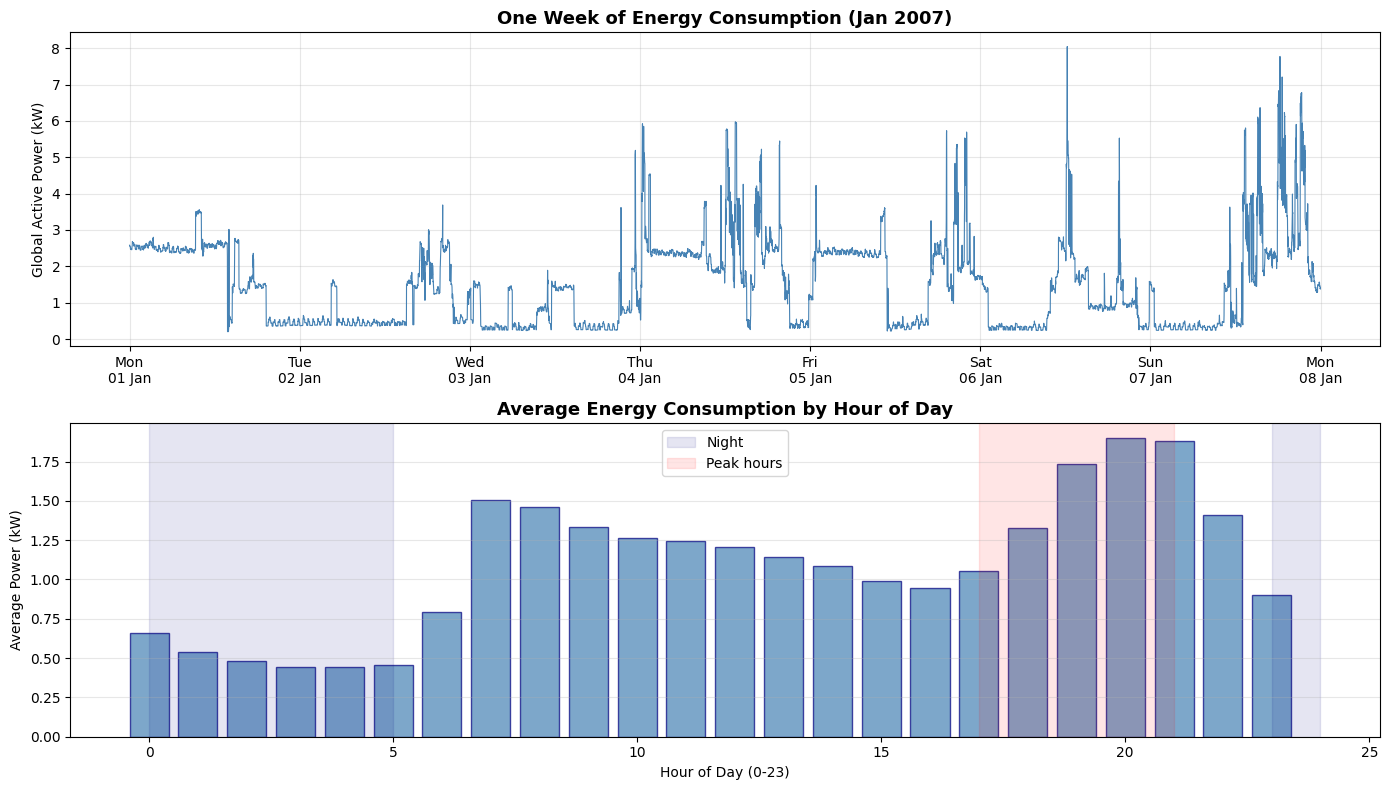

Chart saved to docs/datetime_patterns.png

What to look for:
  Plot 1: Should show daily cycles — higher in evenings
  Plot 2: Should show low usage at night, peak in evening
  If patterns make sense — datetime parsing is correct!


In [11]:
# visualize to confirm datetime parsing worked
#
# Always visualize after major data transformations.
# If the plot looks wrong — parsing was wrong.
# If it shows sensible energy patterns — we're good.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1 — one week of data to see daily patterns
one_week = df['Global_active_power']['2007-01-01':'2007-01-07']
axes[0].plot(one_week.index, one_week.values,
             color='steelblue', linewidth=0.8)
axes[0].set_title('One Week of Energy Consumption (Jan 2007)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Global Active Power (kW)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
axes[0].grid(True, alpha=0.3)

# Plot 2 — average consumption by hour of day
hourly_avg = df.groupby('hour')['Global_active_power'].mean()
axes[1].bar(hourly_avg.index, hourly_avg.values,
            color='steelblue', alpha=0.7, edgecolor='navy')
axes[1].set_title('Average Energy Consumption by Hour of Day',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_ylabel('Average Power (kW)')
axes[1].axvspan(23, 24, alpha=0.1, color='navy', label='Night')
axes[1].axvspan(0, 5, alpha=0.1, color='navy')
axes[1].axvspan(17, 21, alpha=0.1, color='red', label='Peak hours')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../docs/datetime_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/datetime_patterns.png")
print("\nWhat to look for:")
print("  Plot 1: Should show daily cycles — higher in evenings")
print("  Plot 2: Should show low usage at night, peak in evening")
print("  If patterns make sense — datetime parsing is correct!")

In [13]:
# document the processed dataset
#
# We don't save the full dataframe to disk yet —
# it's 338MB in RAM and we'll keep transforming it.
# But we document its current state clearly.

print("="*55)
print("PROCESSED DATASET STATE AFTER DAY 5")
print("="*55)
print(f"\nShape: {df.shape}")
print(f"\nIndex: datetime (properly parsed)")
print(f"  Range: {df.index[0]} to {df.index[-1]}")
print(f"  Sorted: {df.index.is_monotonic_increasing}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

PROCESSED DATASET STATE AFTER DAY 5

Shape: (2075259, 15)

Index: datetime (properly parsed)
  Range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
  Sorted: True

Columns (15):
  Global_active_power: float64
  Global_reactive_power: float64
  Voltage: float64
  Global_intensity: float64
  Sub_metering_1: float64
  Sub_metering_2: float64
  Sub_metering_3: float64
  hour: int32
  day_of_week: int32
  month: int32
  year: int32
  day_of_year: int32
  is_weekend: int64
  is_night: int64
  is_peak_hours: int64

Missing values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
